In [1]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 





In [2]:
df_maxbmb =pd.read_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max.csv')
df_maxbmb_2k =pd.read_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')
df_maxbmb_2100 =pd.read_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_n_2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv')
df_ms_2K = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')
df_ms_n_2K = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_TFuntil2K.csv')

df_ms_o = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max.csv')
df_ms_n_o = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept.csv')


df_ms_all=[df_ms_o ,df_ms_2100,df_ms_2K]
df_ms_n_all=[df_ms_n_o ,df_ms_n_2100,df_ms_n_2K]



for df_ms in df_ms_all:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
#     df_ms['Aurora']=df_ms['sector_8']
#     df_ms['Wilkes']=df_ms['sector_7']
    
for df_ms_n in df_ms_n_all:    
    df_ms_n['WestAntarctica'] = df_ms_n['region_1']
    df_ms_n['EastAntarctica'] = df_ms_n['region_2']
    df_ms_n['Peninsula'] = df_ms_n['region_3']
#     df_ms_n['Aurora']=df_ms_n['sector_8']
#     df_ms_n['Wilkes']=df_ms_n['sector_7']



# df_maxbmb_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_lincomb.csv')
# df_maxbmb_2k_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_TFuntil2K_lincomb.csv')
# df_maxbmb_2100_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_time2100_lincomb.csv')
df_best = df_maxbmb.copy()
dfs = [df_maxbmb,df_maxbmb_2100,df_maxbmb_2k]
dfs_string = ['df_maxbmb','df_maxbmb_2100','df_maxbmb_2k']

regions = df_maxbmb.columns[4:].values.tolist()
regions = ['AIS',
 'Amundsen',
 'Ross',
 'FilchnerRonne',
           'Aurora',
           'Wilkes'
    ]
regions_all= regions.copy()
regions1= regions[1:]
regions_all1=regions1.copy()
experiments = np.unique(df_maxbmb["Experiment"])
df_exp = df_maxbmb[df_maxbmb['Experiment']== experiments[0]].reset_index(drop=True)
df_best = df_exp.copy()
models = df_exp.Model.values
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
   ]
scatters = ['.','+','^','v']
df_best = df_best.drop(df_best.columns[0:2],axis=1)
df_best = df_best.drop(df_best.columns[1:11],axis=1)
df_best['mean-error']=1e15
df_best['method']='nan'
df_best['parameterization']='nan'

for region in regions:
    df_best[f'melt_sensetivity_{region}']=0
    df_best[f'melt_sensetivity_intercept_{region}']=0
    


# df_best2= df_best.copy()
# regions2 = ['Ross', 'FilchnerRonne']
colors2 = ['darksalmon','coral','olive']


In [3]:
regions

['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

VUWOISM  [27.57406469 22.47575886 15.75145076]
VUWOISM  [15.96243384 10.57375647 11.55102023]
VUWOISM  [13.25116893  9.44184576 10.22504712]
VUWOISM  [23.13110583  8.71535134 27.79319126]
VUWOISM  [14.26281741 10.63187743 12.5074461 ]
VUWOISM  [13.9783811  13.35988367 15.41232274]
VUWOPISM s2 all 
VUWOPISM s2 all 
VUWOPISM s2 all 
VUWOPISM s2 all 
VUWOPISM s2 all 
VUWOPISM s2 wilkes [24.06076114 19.71351417 13.39668533]


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_22011/3144382107.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

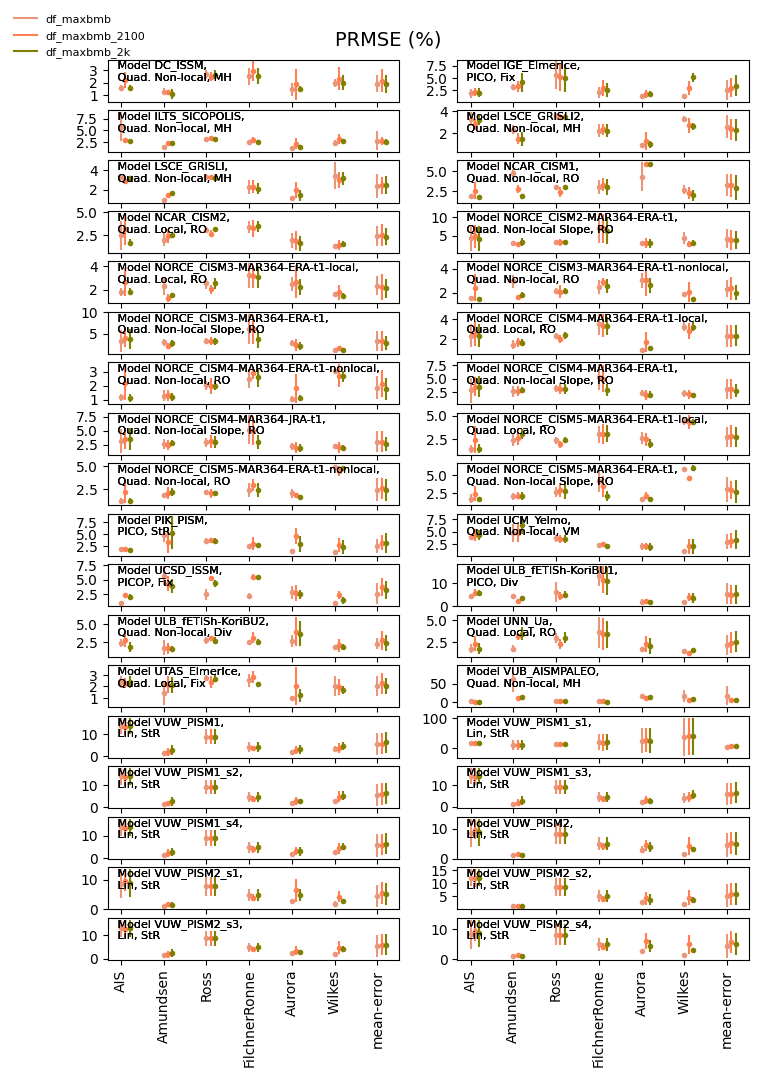

In [4]:
a4_width = 8.27  # inches
a4_height = 11.69
fs = 8
f, ax2 = plt.subplots(int(len(models)/2),2,figsize = (a4_width,a4_height),sharex = True)
for l,df in enumerate(dfs):
    #iterarte through 3 methofd mabmb ,2k,2100
    df_ms = df_ms_all[l].copy()
    df_ms_n = df_ms_n_all[l].copy()
    
   
    for i,Mod in enumerate(models):
        #iterarte though model nams
        best = 1e15
        
        dfmodel = df[df['Model']== Mod]
        df_ms_model = df_ms[df_ms['Model']== Mod]
        df_ms_n_model =df_ms_n[df_ms_n['Model']== Mod] 
        
       
        for j,region in enumerate(regions):
#             iterate though regions
            mn =np.nanmean(dfmodel[f'{region}'].values).copy() #get mean from all 4 exp for one region
            std =np.nanstd(dfmodel[f'{region}'].values).copy()
                
                
            ax = ax2[i//2,i%2]
            ax.errorbar(j+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        #now  take again the mean for each methof  of all reions of interest, do not use VUW_PISMv1_s1
        if Mod == 'VUW_PISM1_s1':
            mn =np.nanmean(dfmodel[regions].values[1:]).copy()
            std =np.nanstd(dfmodel[regions].values[1:]).copy()
        else:
            mn =np.nanmean(dfmodel[regions].values).copy()
            std =np.nanstd(dfmodel[regions].values).copy()
        ax.errorbar(j+1+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        df_best.iloc[i,1] = np.min([df_best.iloc[i,1],mn]).copy() #get mininimum of the means 
        if df_best.iloc[i,1] == mn:
            #assign method if meinimum is written in in the data frame:
            df_best.iloc[i,2]=dfs_string[l]
            # get ms-mean woth same method for all regions
            for region in regions:
                
                if Mod == 'VUW_PISM1_s1':
                    df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values[1:]).copy()
                    df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values[1:]).copy()
                    print('VUWOISM ',df_ms_model[region].values[1:])
                elif Mod == 'VUW_PISM1_s3':
                    if (region == 'Wilkes'):
                        df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values[:-1]).copy()
                        df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values[:-1]).copy()
                        print('VUWOPISM s2 wilkes',df_ms_model[region].values[:-1])
                    else:
                        df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
                        df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
                        print('VUWOPISM s2 all ')
                    
                else:
                    df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
                    df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
            
            
        df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
        df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
        df_best.iloc[i,3]= meltparam
        meth = df_best.iloc[i,2].split('_')[-1]
        
        icefront =  df_info_model_exp['ice front'].values[0]
        ax.text(0.02, 0.98,f' Model {Mod},\n {meltparam}, {icefront} ',transform=ax.transAxes,fontsize = fs, va='top',color = 'black')
#         ax.set_ylabel('PRMSE(%)',fontsize=6)
#                 ax.scatter(j,dfmodel[f'{region}'].values,color = colors[k],marker = scatters[l])
#                 ax.set_title(f'{region}')
for i in range(df_best.shape[0]):
    ax = ax2[i//2,i%2]
#     ax.scatter(j+1+3*0.1,df_best.iloc[i,1],color = 'black',marker='.')
#     ax.text(j+1+3*0.1,df_best.iloc[i,1],df_best.iloc[i,2].split('_')[-1] ,fontsize = 6)
ax = ax2[i//2,i%2]
regions_all.append('mean-error')

ax.set_xticks(np.arange(len(regions_all))  )
ax.set_xticklabels(regions_all, rotation=90)
ax = ax2[i//2,0]
 
ax.set_xticks(np.arange(len(regions_all))  )

ax.set_xticklabels(regions_all, rotation=90)

df_best.to_csv('tables/best_ms_method_per_model.csv')
lines = [plt.Line2D([0], [0], color=color) for color in colors2]
f.legend(lines, dfs_string, loc='center left', bbox_to_anchor=(0, 0.9),fontsize = 8,frameon = False)
ax2[0,0].text(5,5,'PRMSE (%)',fontsize = 14)
# plt.tight_layout(rect=[0, 0, 0.85, 0.95])
f.savefig('figs/SI/Fig1.pdf')
f.savefig('figs/SI/Fig1.jpeg')


# ax2[0].text(0.3,1,'for maxBMB',transform=ax2[0].transAxes,fontsize = 15)

In [41]:
Mod

'VUW_PISM2_s4'

In [42]:
dfmodel

,Unnamed: 0,Experiment,Model,Path,AIS,Amundsen,Ross,FilchnerRonne,Aurora,Wilkes,WestAntarctica,EastAntarctica,Peninsula
35,35,expAE02,VUW_PISM2_s4,/Volumes/CrucialX8/computing/data/antarctica/i...,7.393276,0.887644,2.923892,3.565988,1.814276,3.214779,1.732486,8.996826,28.783798
71,71,expAE03,VUW_PISM2_s4,/Volumes/CrucialX8/computing/data/antarctica/i...,2.623091,0.620214,11.203669,5.588206,4.888285,2.405103,1.726495,25.470969,3.536889
107,107,expAE04,VUW_PISM2_s4,/Volumes/CrucialX8/computing/data/antarctica/i...,15.100452,1.504424,7.267195,2.466656,3.561623,3.077642,1.517733,15.832669,6.983835
143,143,expAE05,VUW_PISM2_s4,/Volumes/CrucialX8/computing/data/antarctica/i...,9.007410,1.245142,11.110345,8.177579,6.935193,4.018199,6.207088,16.576785,16.454305


### Group by AIS -, regions-mean (amundesen,FRIS,ROSS) and EAST,WEST ) module score


In [43]:
index =np.argsort(df_best['mean-error'].values)
df_area_change_all = pd.read_csv('tables/precentage_change_ofIceShelf.csv')
p_change = np.zeros(len(index))
for i,Model in enumerate(df_best['Model'].values[index]):
    df = df_area_change_all[df_area_change_all['Model']==Model]
    p_change[i] = np.nanmean(df.AIS.values)

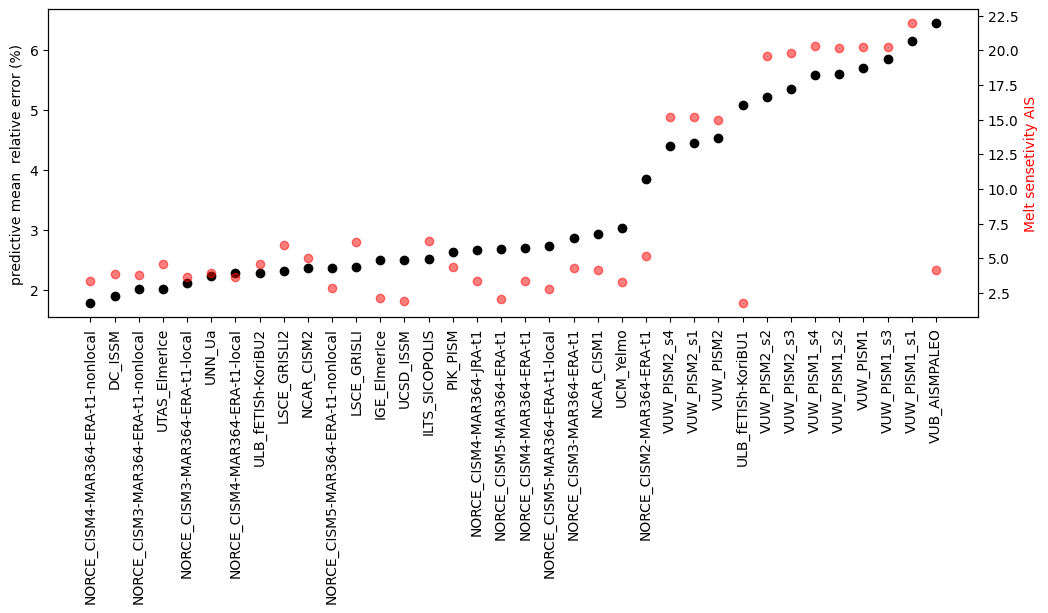

In [44]:
f,ax = plt.subplots(1,1,figsize =(12,4))
ax2 = ax.twinx()
ax.scatter(np.arange(len(index)),df_best['mean-error'].values[index],color = 'black')
# for i in range(len(index)):
#     ax.annotate(df_best['parameterization'].values[index][i],(i,df_best['mean-error'].values[index][i]),rotation = 90)


ax.set_xticks(np.arange(len(index)))
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90)
ax.set_ylabel('predictive mean  relative error (%)')
ax2.scatter(np.arange(len(index)),df_best['melt_sensetivity_AIS'].values[index], color = 'red',alpha =  0.5)
# 
ax2.set_ylabel('Melt sensetivity AIS',color = 'red')
f.savefig('figs/SI/predictive_mean_error_and_sensitivity.pdf')
f.savefig('figs/SI/predictive_mean_error_and_sensitivity.jpeg')



## Main Figure

### Creates the mins and max from the methods 

In [5]:
df_best_min_max= df_best.copy()

In [6]:
index =np.argsort(df_best['melt_sensetivity_AIS'].values)
index = index[::-1]
for region in regions:
    df_best_min_max[f'max_melt_sensetivity_{region}']=0
    df_best_min_max[f'min_melt_sensetivity_{region}']=0

In [7]:
clname = df_best_min_max.columns
i_clname = np.arange(0,clname.size)


for i in range(df_best_min_max.shape[0]):
    method = df_best_min_max.iloc[i]['method']
    Model = df_best_min_max.iloc[i]['Model']
#     print(method)
    ids =np.asarray([0,1,2])
    k =ids[ method==np.asarray( dfs_string)][0]
    df_method =df_ms_all[k]
#     print('check mehtod, ' ,dfs_string[k])
    
    
    df_method_Model = df_method[df_method.Model== Model]
    for region in regions:
        i_y =i_clname[clname== f'max_melt_sensetivity_{region}'][0]
        i_y2 =i_clname[clname== f'min_melt_sensetivity_{region}'][0]
        if Model == 'VUW_PISM1_s1':
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values[1:].max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values[1:].min()
            print(Model)
            print(df_method_Model[region].values[1:])
        elif (Model == 'VUW_PISM1_s3') & (region == 'Wilkes'):
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values[:-1].max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values[:-1].min()
            
        else:
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values.max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values.min()
#         print(Model)
      
#         print(df_best_min_max['Model'].values[i])
        

        
        
        


VUW_PISM1_s1
[27.57406469 22.47575886 15.75145076]
VUW_PISM1_s1
[15.96243384 10.57375647 11.55102023]
VUW_PISM1_s1
[13.25116893  9.44184576 10.22504712]
VUW_PISM1_s1
[23.13110583  8.71535134 27.79319126]
VUW_PISM1_s1
[14.26281741 10.63187743 12.5074461 ]
VUW_PISM1_s1
[13.9783811  13.35988367 15.41232274]


In [56]:
len(regions)

6

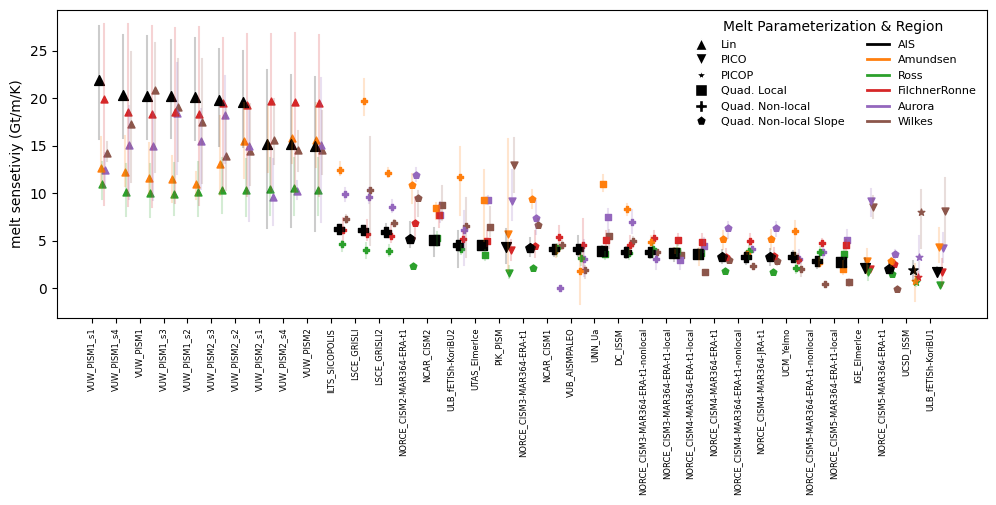

In [8]:
param_u =np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
dic_marker = {}
for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization'][index]:
    markers.append(dic_marker[key])

for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i,region in enumerate(regions[::-1]):
    y = df_best_min_max[f'melt_sensetivity_{region}'].values[index]
    y_err_lower = df_best_min_max[f'min_melt_sensetivity_{region}'].values[index]
    y_err_upper =df_best_min_max[f'max_melt_sensetivity_{region}'].values[index] 
    xall = np.arange(len(index))*8+5 -0.5 *i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x,ym ,marker=markers[j],  color=colors[::-1][i],s = 50)
        else:
            plt.scatter(x,ym ,marker=markers[j],  color=colors[::-1][i],s=25)
        
        plt.plot([x,x],[yl,yu] ,  color=colors[::-1][i],alpha =0.2)
        
#     break

ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('melt sensetiviy (Gt/m/K)')
# 


# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=param_u[i]) 
                  for i in range(len(param_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]
# Combine marker and color legends into one
combined_handles = marker_handles + color_handles
combined_labels = param_u.tolist() + regions

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Melt Parameterization & Region", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)
# Your existing code here...

# Save the figure with tight bounding box
f.savefig('figs/paper/melt_sensetivity_region.pdf', bbox_inches='tight')
f.savefig('figs/paper/melt_sensetivity_region.jpeg', bbox_inches='tight')


In [62]:
i

5

In [76]:
y_err_lower

array([0.4035051 , 1.08255134, 0.3088232 , 0.4533892 , 0.52392557,
       0.66255488, 0.39259439, 0.82003417, 0.74752708, 0.69263319,
       0.43163754, 0.78919861, 0.59680628, 0.6802142 , 0.55737169,
       0.74153282, 0.76060161, 0.90221146, 1.70263554, 0.32695546,
       2.36192084, 1.68787843, 0.83407365, 0.53964046, 0.54802256,
       0.43473457, 8.938835  , 8.72382825, 8.89475519, 4.72916248,
       4.86281283, 4.56402783, 4.40578963, 4.55493148, 4.54510436,
       6.18230734])

NameError: name 'df_best2' is not defined

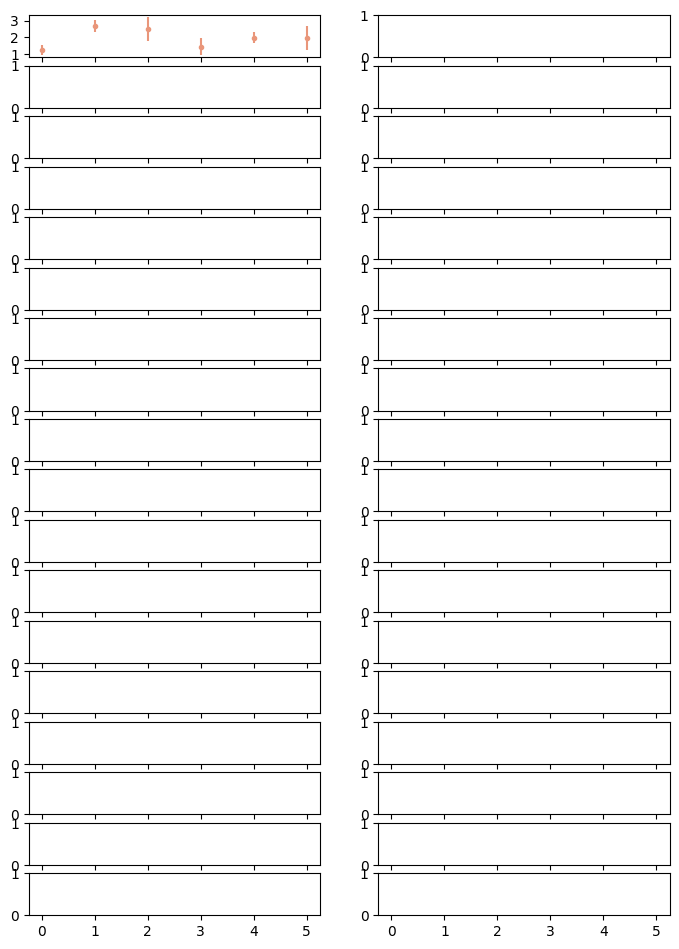

In [77]:
#no AIS


a4_width = 8.27  # inches
a4_height = 11.69
fs = 8
f, ax2 = plt.subplots(int(len(models)/2),2,figsize = (a4_width,a4_height),sharex = True)
for l,df in enumerate(dfs):
   
    for i,Mod in enumerate(models):
        best = 1e15
        dfmodel = df[df['Model']== Mod]
       
        for j,region in enumerate(regions1):
            mn =np.nanmean(dfmodel[f'{region}'].values)
            std =np.nanstd(dfmodel[f'{region}'].values)
                
                
            ax = ax2[i//2,i%2]
            ax.errorbar(j+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        mn =np.nanmean(dfmodel[regions1].values)
        std =np.nanstd(dfmodel[regions1].values)
        ax.errorbar(j+1+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        df_best2.iloc[i,1] = np.min([df_best2.iloc[i,1],mn])
        if df_best2.iloc[i,1] == mn:
            df_best2.iloc[i,2]=dfs_string[l]
        
        df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
        df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
        icefront =  df_info_model_exp['ice front'].values[0]
        df_best2.iloc[i,3]= meltparam
        
        ax.text(0.02, 0.98,f' Model {Mod},\n {meltparam}, {icefront} ',transform=ax.transAxes,fontsize = fs, va='top',color = 'black')

#                 ax.scatter(j,dfmodel[f'{region}'].values,color = colors[k],marker = scatters[l])
#                 ax.set_title(f'{region}')
for i in range(df_best.shape[0]):
    ax = ax2[i//2,i%2]
    ax.scatter(j+1+3*0.1,df_best2.iloc[i,1],color = 'black',marker='.')
    ax.text(j+1+3*0.1,df_best2.iloc[i,1],df_best2.iloc[i,2] ,fontsize = 6)
ax = ax2[i//2,i%2]
regions_all.append('mean')

ax.set_xticks(np.arange(len(regions_all1))  )
ax.set_xticklabels(regions_all1, rotation=90)
ax = ax2[i//2,0]
 
ax.set_xticks(np.arange(len(regions_all1))  )

ax.set_xticklabels(regions_all1, rotation=90)
df_best2.to_csv('tables/best_ms_method_per_model_noAIS.csv')

# ax2[0].text(0.3,1,'for maxBMB',transform=ax2[0].transAxes,fontsize = 15)

In [9]:
mask = df_best.method.values == df_best2.method.values
df_best2.Model.values[~mask]

array(['NORCE_CISM4-MAR364-ERA-t1-nonlocal'], dtype=object)

In [190]:
df_best2.method.values[~mask]

array(['df_maxbmb_2k', 'df_maxbmb', 'df_maxbmb_2k', 'df_maxbmb_2k',
       'df_maxbmb_2100', 'df_maxbmb_2100', 'df_maxbmb_2100'], dtype=object)

In [196]:
df_best2

,Model,mean,method,parameterization
0,DC_ISSM,7.437300e+11,df_maxbmb,Quad. Non-local
1,IGE_ElmerIce,6.656421e+11,df_maxbmb,PICO
2,ILTS_SICOPOLIS,1.770106e+12,df_maxbmb_2k,Quad. Non-local
3,LSCE_GRISLI2,6.730826e+11,df_maxbmb_2100,Quad. Non-local
4,LSCE_GRISLI,8.621401e+11,df_maxbmb_2100,Quad. Non-local
5,NCAR_CISM1,8.374484e+11,df_maxbmb_2k,Quad. Non-local
6,NCAR_CISM2,1.464402e+12,df_maxbmb_2k,Quad. Local
7,NORCE_CISM2-MAR364-ERA-t1,2.013450e+12,df_maxbmb_2k,Quad. Non-local Slope
8,NORCE_CISM3-MAR364-ERA-t1-local,8.044528e+11,df_maxbmb_2k,Quad. Local
9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,6.655229e+11,df_maxbmb_2k,Quad. Non-local


### Which method lincomb or overall MS???

In [ ]:
regions2 = ['Ross', 'FilchnerRonne']
colors2 = ['darksalmon','coral','olive','yellow','cyan','steelblue']

dfs2 =  [df_maxbmb,df_maxbmb_2k,df_maxbmb_2100,df_maxbmb_lc,df_maxbmb_2k_lc,df_maxbmb_2100_lc,]